# F1LAB — 01 Qualifying Weekend Exploration

## Goal

Build our first real pre-qualifying feature table.

Pipeline:

**FastF1 → practice laps → representative laps → features → qualifying target**

First experiment: **2025 Italian Grand Prix**.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

from f1_racelab.features.qualifying import build_weekend_dataset

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## Build one real weekend

Everything below qualifying is legal pre-qualifying information.

`final_position`, `q1_seconds`, `q2_seconds`, `q3_seconds`
are targets and must never become pre-qualifying features.


In [3]:
df = build_weekend_dataset(2025, "Italy")

print("Shape:", df.shape)

df


events      WARNING 	Correcting user input 'Italy' to 'Italian Grand Prix'
core           INFO 	Loading data for Italian Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '61', '63', '87', '89']
events      WARNING 	Correcting user input 'Italy' to 'Italian Grand Prix'
core           INFO 	Loading data for Italian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_inf

Shape: (20, 43)


,year,event,driver,fp1_best_seconds,fp1_top3_median_seconds,fp1_representative_laps,fp1_soft_best_seconds,fp1_theoretical_best_seconds,fp1_best_vs_theoretical,fp1_best_tyre_life,fp1_best_speed_trap,fp1_gap_seconds,fp1_gap_pct,fp1_rank,fp2_best_seconds,fp2_top3_median_seconds,fp2_representative_laps,fp2_soft_best_seconds,fp2_theoretical_best_seconds,fp2_best_vs_theoretical,fp2_best_tyre_life,fp2_best_speed_trap,fp2_gap_seconds,fp2_gap_pct,fp2_rank,fp3_best_seconds,fp3_top3_median_seconds,fp3_representative_laps,fp3_soft_best_seconds,fp3_theoretical_best_seconds,fp3_best_vs_theoretical,fp3_best_tyre_life,fp3_best_speed_trap,fp3_gap_seconds,fp3_gap_pct,fp3_rank,final_position,q1_seconds,q2_seconds,q3_seconds,q1_gap_pct,fp1_to_fp3_improvement_pct,fp2_to_fp3_improvement_pct
19,2025,Italy,VER,80.692,80.751,6.0,80.692,80.620,7.200000e-02,2.0,342.0,0.575,0.717700,4.0,80.077,80.710,3.0,80.077,80.077,0.000000e+00,4.0,340.0,0.199,0.249130,6.0,79.498,79.513,5.0,79.498,79.415,0.083,5.0,345.0,0.167,0.210510,4.0,1.0,79.455,79.140,78.792,0.051628,0.507190,0.038620
12,2025,Italy,NOR,81.021,81.425,8.0,81.021,80.967,5.400000e-02,9.0,336.0,0.904,1.128350,6.0,79.878,80.132,4.0,79.878,79.878,0.000000e+00,3.0,335.0,0.000,0.000000,1.0,79.331,79.492,5.0,79.331,79.296,0.035,2.0,337.0,0.000,0.000000,1.0,2.0,79.517,79.293,78.869,0.129700,1.128350,0.000000
14,2025,Italy,PIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.059,80.352,6.0,80.059,80.046,1.300000e-02,5.0,335.0,0.181,0.226596,4.0,79.496,79.578,6.0,79.496,79.452,0.044,5.0,337.0,0.165,0.207989,3.0,3.0,79.711,79.286,78.982,0.373989,NaN,0.018606
11,2025,Italy,LEC,80.286,80.970,5.0,80.286,80.286,0.000000e+00,6.0,345.0,0.169,0.210941,2.0,79.961,80.399,6.0,79.961,79.961,0.000000e+00,7.0,342.0,0.083,0.103908,2.0,79.352,79.794,6.0,79.352,79.352,0.000,5.0,352.0,0.021,0.026471,2.0,4.0,79.689,79.310,79.007,0.346287,0.184470,0.077437
8,2025,Italy,HAM,80.117,80.763,6.0,80.117,80.117,1.421085e-14,6.0,343.0,0.000,0.000000,1.0,80.070,81.100,3.0,80.070,80.070,0.000000e+00,2.0,341.0,0.192,0.240367,5.0,79.598,79.692,7.0,79.598,79.572,0.026,2.0,348.0,0.267,0.336565,7.0,5.0,79.765,79.371,79.124,0.441988,-0.336565,-0.096198
15,2025,Italy,RUS,81.110,81.146,5.0,81.110,80.957,1.530000e-01,7.0,335.0,0.993,1.239437,8.0,80.276,80.308,5.0,80.276,80.201,7.500000e-02,5.0,336.0,0.398,0.498260,10.0,79.515,79.637,5.0,79.515,79.495,0.020,5.0,341.0,0.184,0.231940,5.0,6.0,79.414,79.287,79.157,0.000000,1.007498,0.266320
2,2025,Italy,ANT,80.940,81.427,6.0,80.940,80.933,7.000000e-03,9.0,339.0,0.823,1.027248,5.0,81.367,81.367,1.0,NaN,81.367,1.421085e-14,2.0,338.0,1.489,1.864093,19.0,79.696,79.861,4.0,79.696,79.695,0.001,5.0,345.0,0.365,0.460098,9.0,7.0,79.747,79.245,79.200,0.419322,0.567150,1.403995
4,2025,Italy,BOR,81.172,81.582,5.0,81.172,81.172,0.000000e+00,6.0,341.0,1.055,1.316824,11.0,80.475,80.484,3.0,80.475,80.351,1.240000e-01,5.0,347.0,0.597,0.747390,12.0,79.558,79.645,4.0,79.558,79.553,0.005,5.0,350.0,0.227,0.286143,6.0,8.0,79.688,79.323,79.390,0.345027,1.030681,0.461247
1,2025,Italy,ALO,81.114,81.192,4.0,81.114,80.934,1.800000e-01,5.0,341.0,0.997,1.244430,9.0,80.645,80.918,4.0,80.645,80.592,5.300000e-02,6.0,341.0,0.767,0.960214,15.0,79.861,80.057,6.0,79.861,79.830,0.031,5.0,343.0,0.530,0.668087,12.0,9.0,79.658,79.362,79.424,0.307251,0.576343,0.292127
18,2025,Italy,TSU,81.292,81.303,5.0,81.292,81.195,9.700000e-02,2.0,334.0,1.175,1.466605,14.0,80.269,81.176,4.0,80.269,80.269,0.000000e+00,2.0,343.0,0.391,0.489496,9.0,80.059,80.249,5.0,80.059,79.982,0.077,5.0,343.0,0.728,0.917674,15.0,10.0,79.619,79.433,79.519,0.258141,0.548931,-0.428178


## Inspect our main V1 features

In [4]:
columns = [
    "driver",
    "fp1_gap_pct",
    "fp2_gap_pct",
    "fp3_gap_pct",
    "fp3_rank",
    "fp3_top3_median_seconds",
    "fp3_theoretical_best_seconds",
    "fp3_best_vs_theoretical",
    "fp3_best_tyre_life",
    "fp3_best_speed_trap",
    "fp1_to_fp3_improvement_pct",
    "final_position",
    "q1_gap_pct",
]

df[columns].sort_values("final_position")


,driver,fp1_gap_pct,fp2_gap_pct,fp3_gap_pct,fp3_rank,fp3_top3_median_seconds,fp3_theoretical_best_seconds,fp3_best_vs_theoretical,fp3_best_tyre_life,fp3_best_speed_trap,fp1_to_fp3_improvement_pct,final_position,q1_gap_pct
19,VER,0.717700,0.249130,0.210510,4.0,79.513,79.415,0.083,5.0,345.0,0.507190,1.0,0.051628
12,NOR,1.128350,0.000000,0.000000,1.0,79.492,79.296,0.035,2.0,337.0,1.128350,2.0,0.129700
14,PIA,NaN,0.226596,0.207989,3.0,79.578,79.452,0.044,5.0,337.0,NaN,3.0,0.373989
11,LEC,0.210941,0.103908,0.026471,2.0,79.794,79.352,0.000,5.0,352.0,0.184470,4.0,0.346287
8,HAM,0.000000,0.240367,0.336565,7.0,79.692,79.572,0.026,2.0,348.0,-0.336565,5.0,0.441988
15,RUS,1.239437,0.498260,0.231940,5.0,79.637,79.495,0.020,5.0,341.0,1.007498,6.0,0.000000
2,ANT,1.027248,1.864093,0.460098,9.0,79.861,79.695,0.001,5.0,345.0,0.567150,7.0,0.419322
4,BOR,1.316824,0.747390,0.286143,6.0,79.645,79.553,0.005,5.0,350.0,1.030681,8.0,0.345027
1,ALO,1.244430,0.960214,0.668087,12.0,80.057,79.830,0.031,5.0,343.0,0.576343,9.0,0.307251
18,TSU,1.466605,0.489496,0.917674,15.0,80.249,79.982,0.077,5.0,343.0,0.548931,10.0,0.258141


## Baseline 0 — FP3 order predicts qualifying

Before ML, we need something to beat.

If our ML model cannot beat this baseline on future races,
the ML model is not useful.


In [5]:
evaluation = df.dropna(
    subset=["fp3_best_seconds", "final_position"]
).copy()

evaluation["fp3_pred_position"] = (
    evaluation["fp3_best_seconds"]
    .rank(method="first")
    .astype(int)
)

mae = mean_absolute_error(
    evaluation["final_position"],
    evaluation["fp3_pred_position"],
)

rho, _ = spearmanr(
    evaluation["final_position"],
    evaluation["fp3_pred_position"],
)

print(f"FP3 baseline MAE:      {mae:.3f} positions")
print(f"FP3 Spearman rho:      {rho:.3f}")

evaluation[
    [
        "driver",
        "fp3_pred_position",
        "final_position",
        "fp3_gap_pct",
        "q1_gap_pct",
    ]
].sort_values("final_position")


FP3 baseline MAE:      2.700 positions
FP3 Spearman rho:      0.823


,driver,fp3_pred_position,final_position,fp3_gap_pct,q1_gap_pct
19,VER,4,1.0,0.210510,0.051628
12,NOR,1,2.0,0.000000,0.129700
14,PIA,3,3.0,0.207989,0.373989
11,LEC,2,4.0,0.026471,0.346287
8,HAM,7,5.0,0.336565,0.441988
15,RUS,5,6.0,0.231940,0.000000
2,ANT,9,7.0,0.460098,0.419322
4,BOR,6,8.0,0.286143,0.345027
1,ALO,12,9.0,0.668087,0.307251
18,TSU,15,10.0,0.917674,0.258141


## Visualize prediction error

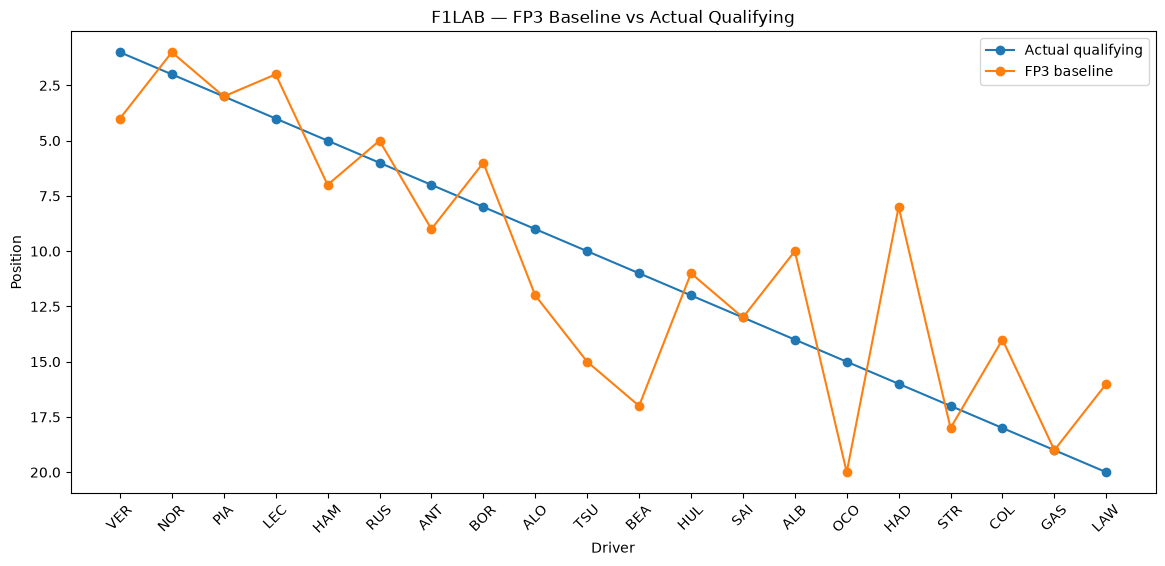

In [6]:
plot_df = evaluation.sort_values("final_position")

x = range(len(plot_df))

plt.figure(figsize=(14, 6))

plt.plot(
    x,
    plot_df["final_position"],
    marker="o",
    label="Actual qualifying",
)

plt.plot(
    x,
    plot_df["fp3_pred_position"],
    marker="o",
    label="FP3 baseline",
)

plt.xticks(
    x,
    plot_df["driver"],
    rotation=45,
)

plt.ylabel("Position")
plt.xlabel("Driver")
plt.title("F1LAB — FP3 Baseline vs Actual Qualifying")
plt.gca().invert_yaxis()
plt.legend()
plt.show()


## Questions before adding ML

1. Which drivers are badly predicted by FP3?
2. Does theoretical sector pace explain any mistakes?
3. Does FP1 → FP3 progression contain useful information?
4. Does top-3 median pace tell a different story from one fastest lap?
5. Which information would have been available before qualifying?

These questions drive our next feature set.
